# 1. Import and Install Dependencies

In [1]:
!pip install tensorflow==2.19.0 opencv-python mediapipe==0.10.7 scikit-learn matplotlib

  Using cached tensorflow-2.19.0-cp311-cp311-win_amd64.whl.metadata (4.1 kB)
  Using cached mediapipe-0.10.7-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
Using cached tensorflow-2.19.0-cp311-cp311-win_amd64.whl (375.9 MB)
Using cached mediapipe-0.10.7-cp311-cp311-win_amd64.whl (50.3 MB)

   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [mediapipe]
   ---------------------------------------- 0/2 [med


[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: C:\Users\nduha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import mediapipe as mp
import cv2

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TF version: 2.19.0
GPU: []


In [3]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. Keypoints using MP Holistic

In [4]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [5]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [6]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [7]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [8]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [9]:
draw_landmarks(frame, results)

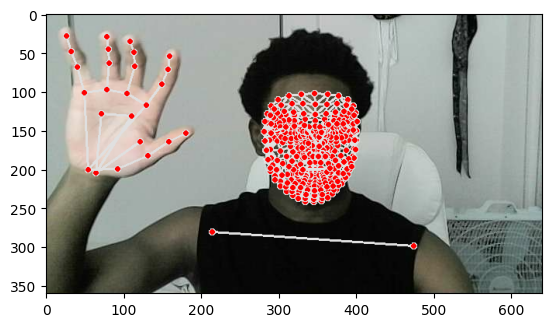

In [10]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [11]:
len(results.right_hand_landmarks.landmark)

21

In [12]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [13]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [14]:
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)


In [16]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [17]:
result_test = extract_keypoints(results)

In [18]:
result_test

array([ 0.55022442,  0.47544679, -0.98747683, ...,  0.04128665,
        0.08151916, -0.05705554])

In [ ]:
#np.save('0', result_test)

In [ ]:
#np.load('0.npy')

array([ 0.45040107,  0.61555821, -1.18524516, ...,  0.01068747,
        0.3806653 , -0.07014321])

# 4. Setup Folders for Collection

In [19]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['hello', 'thanks', 'iloveyou'])

# Sixty videos worth of data
no_sequences = 60

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 0

In [20]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

In [ ]:
#for action in actions: 
#    dirmax = np.max(np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int))
#    for sequence in range(1,no_sequences+1):
#        try: 
#            os.makedirs(os.path.join(DATA_PATH, action, str(dirmax+sequence)))
#        except:
#            pass

# 5. Collect Keypoint Values for Training and Testing

In [59]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # Add pause state variable
    paused = False
    
    # NEW LOOP
    # Loop through actions
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(start_folder, start_folder+no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()
                
                # Display pause message if paused
                if paused:
                    cv2.putText(frame, 'PAUSED - Press P to Resume', (120, 200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 4, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', frame)
                    
                    # Wait for key press while paused
                    key = cv2.waitKey(10) & 0xFF
                    if key == ord('p'):  # Resume if 'p' pressed
                        paused = False
                        print("Resuming collection...")
                        continue
                    elif key == ord('q'):  # Quit if 'q' pressed
                        print("Quitting collection...")
                        cap.release()
                        cv2.destroyAllWindows()
                        exit()
                    else:
                        # Continue loop without collecting
                        continue

                # Make detections
                image, results = mediapipe_detection(frame, holistic)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120, 200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(500)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints (only if not paused)
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Check for pause/quit keys
                key = cv2.waitKey(10) & 0xFF
                if key == ord('p'):  # Pause if 'p' pressed
                    paused = True
                    print("Paused collection. Press P to resume.")
                    # Skip the rest of this frame's processing
                    frame_num -= 1  # Stay on same frame number
                    continue
                elif key == ord('q'):  # Quit if 'q' pressed
                    print("Quitting collection...")
                    cap.release()
                    cv2.destroyAllWindows()
                    exit()
                    
    cap.release()
    cv2.destroyAllWindows()

Paused collection. Press P to resume.
Resuming collection...
Paused collection. Press P to resume.
Resuming collection...


In [85]:
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features

In [60]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [61]:
label_map = {label:num for num, label in enumerate(actions)}

In [62]:
label_map

{np.str_('hello'): 0, np.str_('thanks'): 1, np.str_('iloveyou'): 2}

In [63]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [64]:
np.array(sequences).shape

(180, 30, 1662)

In [65]:
np.array(labels).shape

(180,)

In [66]:
X = np.array(sequences)

In [67]:
X.shape

(180, 30, 1662)

In [68]:
y = to_categorical(labels).astype(int)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [70]:
y_test.shape

(9, 3)

# 7. Build and Train LSTM Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [163]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [ ]:
# Callbacks (with ReduceLROnPlateau, NO learning rate schedule)
#callbacks = [
#    tb_callback,
#    EarlyStopping(
#        monitor='val_accuracy',
#        patience=30,
#        restore_best_weights=True,
#        verbose=1
#    ),
#    ReduceLROnPlateau(
#        monitor='val_accuracy',
#        factor=0.5,
#        patience=15,
#        min_lr=0.000001,
#        verbose=1
#    ),
#    ModelCheckpoint(
#        'best_model.keras',
#        monitor='val_accuracy',
#        save_best_only=True,
#        verbose=1
#    )
#]

In [ ]:
## Load one sample to get the shape
#sample = np.load(os.path.join(DATA_PATH, actions[0], '0', '0.npy'))
#num_features = len(sample)  # This is your feature count
#
#print(f"Number of features: {num_features}")

Number of features: 1662


In [ ]:
#model = Sequential([
#    # Layer 1: LSTM with dropout
#    LSTM(128, return_sequences=True, 
#         kernel_regularizer=l2(0.001),  # L2 regularization
#         input_shape=(sequence_length, num_features)),
#    BatchNormalization(),
#    Dropout(0.3),
#    
#    # Layer 2: LSTM with dropout  
#    LSTM(256, return_sequences=True, 
#         kernel_regularizer=l2(0.001)),
#    BatchNormalization(),
#    Dropout(0.3),
#    
#    # Layer 3: LSTM
#    LSTM(128, return_sequences=False,
#         kernel_regularizer=l2(0.001)),
#    BatchNormalization(),
#    Dropout(0.3),
#    
#    # Dense layers
#    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
#    BatchNormalization(),
#    Dropout(0.4),
#    
#    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
#    Dropout(0.4),
#    
#    # Output layer
#    Dense(actions.shape[0], activation='softmax')
#])

C:\Users\nduha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
## Learning rate schedule
##initial_learning_rate = 0.001
##lr_schedule = ExponentialDecay(
##    initial_learning_rate,
##    decay_steps=1000,      # Reduce every 1000 steps
##    decay_rate=0.9,        # Reduce by 10%
##    staircase=True
##)
#
## Optimizer with gradient clipping
#optimizer = Adam(
#    learning_rate=0.001,
#    clipnorm=1.0           # Prevent exploding gradients
#)
#
#model.compile(
#    optimizer=optimizer,
#    loss='categorical_crossentropy',
#    metrics=['accuracy']
#)

In [ ]:
## Split data properly
#from sklearn.model_selection import train_test_split
#
#X_train, X_val, y_train, y_val = train_test_split(
#    X, y, 
#    test_size=0.2, 
#    random_state=42,
#    stratify=y  # Maintain class distribution
#)
#
## Train with validation
#history = model.fit(
#    X_train, y_train,
#    validation_data=(X_val, y_val),
#    epochs=500,  # Let early stopping decide actual epochs
#    batch_size=32,
#    callbacks=callbacks,
#    verbose=1
#)

Epoch 1/500
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3333 - loss: 4.0219
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.3681 - loss: 3.6798 - val_accuracy: 0.3333 - val_loss: 2.6652 - learning_rate: 0.0010
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4752 - loss: 2.9319
Epoch 2: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5139 - loss: 2.8299 - val_accuracy: 0.3333 - val_loss: 2.6649 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5186 - loss: 2.6780
Epoch 3: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5694 - loss: 2.6731 - val_accuracy: 0.3333 - val_loss: 2.6468 - learning_rate: 0.0010
Epoch 4/500
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6910 - loss: 2.2827
Epoch 4: 

In [ ]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [ ]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [ ]:
model.fit(X_train, y_train, epochs=700, callbacks=[tb_callback])

In [172]:
#model.save('new_trial_action.keras')

In [173]:
#model.load_weights('new_trial_action.keras')

In [174]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 30, 128)        │       916,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 30, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,605,067 (17.57 MB)

 Trainable params: 1,534,595 (5.85 MB)

 Non-trainable params: 1,280 (5.00 KB)

 Optimizer params: 3,069,192 (11.71 MB)

# 8. Make Predictions

In [175]:
res = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step


In [176]:
actions[np.argmax(res[4])]

np.str_('hello')

In [177]:
actions[np.argmax(y_test[4])]

np.str_('hello')

# 9. Save Weights

In [ ]:
#model.save('action.keras')

In [ ]:
model.save('new_trial_action.keras')

In [ ]:
#del model

In [ ]:
#model.load_weights('action.keras')

In [ ]:
model.load_weights('new_trial_action.keras')

# 10. Evaluation using Confusion Matrix and Accuracy

In [178]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [179]:
yhat = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [180]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [181]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[4, 0],
        [0, 5]],

       [[8, 0],
        [0, 1]],

       [[6, 0],
        [0, 3]]])

In [182]:
accuracy_score(ytrue, yhat)

1.0

# 11. Test in Real Time

In [183]:
from scipy import stats

In [184]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [185]:
#plt.figure(figsize=(18,18))
#plt.imshow(prob_viz(res, actions, image, colors))

In [186]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti